# Imports

In [1]:
import pandas as pd
"""
Lightweight EDA helpers for raw exploratory analysis.
Dependencies: pandas, numpy, matplotlib, seaborn (optional), plotly, sklearn, wordcloud
"""
from collections import Counter
import logging
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix
from typing import List, Optional
from wordcloud import WordCloud

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# Functions

In [2]:
def summarize_df(df: pd.DataFrame) -> pd.DataFrame:
    """Return summary: dtype, non-null count, missing pct, unique, sample values."""
    s = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=False)
    })
    s["sample_values"] = [df[col].dropna().unique()[:5].tolist() for col in df.columns]
    return s


def missing_report(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    """Return top_n columns with highest missing percentage."""
    mr = (df.isna().mean() * 100).sort_values(ascending=False)
    return mr.head(top_n).to_frame("missing_pct")


def numeric_columns(df: pd.DataFrame) -> List[str]:
    return df.select_dtypes(include=[np.number]).columns.tolist()


def plot_distributions(df: pd.DataFrame, cols: Optional[List[str]] = None, bins: int = 30, figsize=(12, 8)):
    """Plot histograms for numeric columns (subset if cols provided)."""
    cols = cols or numeric_columns(df)
    n = len(cols)
    if n == 0:
        logger.info("No numeric columns to plot.")
        return
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=bins, color="#4C72B0")
        ax.set_title(col)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, cols: Optional[List[str]] = None, method: str = "spearman", figsize=(10, 8)):
    """Plot correlation heatmap for numeric columns."""
    cols = cols or numeric_columns(df)
    if len(cols) < 2:
        logger.info("Need at least two numeric columns for correlation.")
        return
    corr = df[cols].corr(method=method)
    if sns:
        plt.figure(figsize=figsize)
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
        plt.title(f"{method} correlation")
        plt.show()
    else:
        plt.figure(figsize=figsize)
        plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
        plt.colorbar()
        plt.xticks(range(len(cols)), cols, rotation=90)
        plt.yticks(range(len(cols)), cols)
        plt.title(f"{method} correlation (seaborn not installed)")
        plt.show()

def plot_pairplot_sample(df: pd.DataFrame, cols: Optional[List[str]] = None, sample_frac: float = 0.2, max_cols: int = 6):
    """Quick pairplot for a sample of numeric columns (uses seaborn if available)."""
    cols = cols or numeric_columns(df)
    cols = cols[:max_cols]
    sample = df[cols].sample(frac=min(1.0, sample_frac), random_state=0)
    if sns:
        sns.pairplot(sample)
        plt.show()
    else:
        logger.info("seaborn not installed; skipping pairplot.")

def plot_pairplot_sample(df: pd.DataFrame, cols: Optional[List[str]] = None, sample_frac: float = 0.2, max_cols: int = 6, hue: Optional[str] = None):
    """Quick pairplot for a sample of numeric columns using plotly (interactive)."""
    cols = cols or numeric_columns(df)
    cols = cols[:max_cols]
    if len(cols) == 0:
        logger.info("No numeric columns to plot.")
        return
    # include hue column in sample if provided and present
    sample_cols = cols[:] 
    if hue and hue in df.columns and hue not in sample_cols:
        sample_cols.append(hue)
    sample = df[sample_cols].sample(frac=min(1.0, sample_frac), random_state=0)
    try:
        import plotly.express as px
    except Exception:
        logger.info("plotly not installed; skipping pairplot.")
        return
    if hue and hue in sample.columns:
        fig = px.scatter_matrix(sample, dimensions=cols, color=hue)
    else:
        fig = px.scatter_matrix(sample, dimensions=cols)
    # adjust layout for readability
    fig.update_layout(height=900, width=min(1200, 200 * len(cols)), title="Interactive Scatter Matrix")
    fig.show()

def detect_outliers_zscore(series: pd.Series, thresh: float = 3.0) -> pd.Series:
    """Return boolean mask where True indicates an outlier by z-score."""
    s = series.dropna()
    mean = s.mean()
    std = s.std()
    if std == 0 or np.isnan(std):
        return pd.Series(False, index=series.index)
    z = (series - mean).abs() / std
    return z > thresh

def plot_outliers(series: pd.Series, thresh: float = 3.0):
    """Plot a series with outliers highlighted."""
    outliers = detect_outliers_zscore(series, thresh)
    plt.figure(figsize=(10, 4))
    plt.plot(series.index, series.values, label="Data", color="#4C72B0")
    plt.scatter(series.index[outliers], series.values[outliers], color="#C44E52", label="Outliers")
    plt.title(f"Outlier Detection (z-score > {thresh})")
    plt.xlabel("Index")
    plt.ylabel(series.name)
    plt.legend()
    plt.show()

def encode_categorical_summary(df: pd.DataFrame, cat_cols: Optional[List[str]] = None, top_n: int = 10) -> pd.DataFrame:
    """Return frequency tables for categorical columns (top_n values)."""
    cat_cols = cat_cols or df.select_dtypes(include=["object", "category"]).columns.tolist()
    out = {}
    for c in cat_cols:
        out[c] = df[c].value_counts(dropna=False).head(top_n)
    # Convert to DataFrame with MultiIndex for easy inspection
    return pd.concat(out, axis=1)


def save_profile_report(df: pd.DataFrame, path: str = "pandas_profile_report.html"):
    """Save a pandas-profiling (ydata-profiling) report if available."""
    try:
        from ydata_profiling import ProfileReport
    except Exception:
        logger.error("ydata-profiling not installed. Install with: pip install ydata-profiling")
        return
    profile = ProfileReport(df, minimal=True)
    profile.to_file(path)
    logger.info("Saved profile report to %s", path)


def show_class_balance(
    df: pd.DataFrame, col: str = "recommended", top_n: Optional[int] = None
) -> None:
    """
    Show class counts, proportions, and a bar chart for any boolean or categorical column.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the column.
    col : str
        The name of the column to analyze (default 'recommended').
    top_n : int, optional
        If set, show only the top_n most frequent categories (useful for high-cardinality columns).
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not in dataframe.")
    class_counts = df[col].value_counts(dropna=False)
    if top_n is not None:
        class_counts = class_counts.head(top_n)
    print(f"Class balance for '{col}':")
    print(class_counts)
    class_proportions = (
        df[col].value_counts(normalize=True, dropna=False)
        .reindex(class_counts.index)
        .fillna(0)
    )
    print(f"\nClass proportions for '{col}':")
    print(class_proportions)
    plt.figure(figsize=(6, 4))
    class_counts.plot(kind="bar")
    plt.title(f"Class balance of '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    if len(class_counts) > 6:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def show_votes_helpful_distribution(
    df: pd.DataFrame,
    col: str = "votes_helpful",
    bins: int = 50,
    y_log: bool = True,
    x_max_percentile: Optional[float] = 99.5,
) -> None:
    """
    Show summary stats and distribution of a vote-like column (e.g. votes_helpful).

    Prints describe() and value_counts().head(10), then a histogram. Uses log scale
    on y by default so the typical spike at 0 and the long tail are both visible.
    Optionally caps x-axis at a percentile so the bulk of the distribution is visible.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the column.
    col : str
        The name of the column (default 'votes_helpful').
    bins : int
        Number of histogram bins.
    y_log : bool
        If True, use log scale on y-axis.
    x_max_percentile : float, optional
        If set, limit x-axis to this percentile of the data (e.g. 99.5) to reduce
        distortion from extreme outliers.
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not in dataframe.")
    series = df[col].dropna()
    print(f"Summary for '{col}':")
    print(series.describe())
    print(f"\nTop value counts:")
    print(series.value_counts().head(10))
    plt.figure(figsize=(8, 4))
    to_plot = series
    if x_max_percentile is not None:
        cap = np.nanpercentile(series, x_max_percentile)
        to_plot = series.clip(upper=cap)
    plt.hist(to_plot, bins=bins, color="#4C72B0", edgecolor="white", alpha=0.8)
    if y_log:
        plt.yscale("log")
    plt.title(f"Distribution of '{col}'" + (f" (x capped at p{x_max_percentile})" if x_max_percentile else ""))
    plt.xlabel(col)
    plt.ylabel("Count" + (" (log)" if y_log else ""))
    plt.tight_layout()
    plt.show()

# Load Data

In [3]:
df_sample = pd.read_csv("../../data/raw/steam_reviews_full.csv", nrows=1_000_000)

In [4]:
df_sample['language'].value_counts()

language
english       392312
russian       185744
schinese      125667
brazilian      45571
turkish        44407
spanish        42013
polish         31777
german         31066
french         26499
koreana        21153
tchinese        8131
czech           7633
italian         5737
portuguese      4249
latam           4034
hungarian       3403
thai            3148
swedish         2676
finnish         2522
danish          2352
dutch           2335
japanese        2113
ukrainian       1820
norwegian       1185
romanian        1068
greek            598
bulgarian        481
vietnamese       306
Name: count, dtype: int64

In [5]:
df_eng = df_sample[df_sample['language']=='english']

In [6]:
pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_columns", None)

# EDA 1: Target variables


In [7]:
df_eng.head(5)

,Unnamed: 0,app_id,app_name,review_id,language,review,timestamp_created,timestamp_updated,recommended,votes_helpful,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,author.steamid,author.num_games_owned,author.num_reviews,author.playtime_forever,author.playtime_last_two_weeks,author.playtime_at_review,author.last_played
3,3,292030,The Witcher 3: Wild Hunt,85184605,english,"One of the best RPG's of all time, worthy of a...",1611379970,1611379970,True,0,0,0.0,0,True,False,False,76561199054755373,5,3,5587.0,3200.0,5524.0,1.611384e+09
5,5,292030,The Witcher 3: Wild Hunt,85184171,english,"good story, good graphics. lots to do.",1611379264,1611379264,True,0,0,0.0,0,True,False,False,76561198170193529,11,1,823.0,823.0,823.0,1.611379e+09
6,6,292030,The Witcher 3: Wild Hunt,85184064,english,"dis gud,",1611379091,1611379091,True,0,0,0.0,0,True,False,False,76561198119302812,27,2,4192.0,3398.0,4192.0,1.611352e+09
18,18,292030,The Witcher 3: Wild Hunt,85180436,english,favorite game of all time cant wait for the Ne...,1611373086,1611373086,True,0,0,0.0,0,True,False,False,76561198065591528,33,1,23329.0,177.0,23329.0,1.611219e+09
20,20,292030,The Witcher 3: Wild Hunt,85179753,english,Why wouldn't you get this,1611371978,1611371978,True,0,0,0.0,0,True,False,False,76561198996835044,131,2,8557.0,2004.0,8557.0,1.611371e+09


In [8]:
df_eng.iloc[0]

Unnamed: 0                                                                        3
app_id                                                                       292030
app_name                                                   The Witcher 3: Wild Hunt
review_id                                                                  85184605
language                                                                    english
review                            One of the best RPG's of all time, worthy of a...
timestamp_created                                                        1611379970
timestamp_updated                                                        1611379970
recommended                                                                    True
votes_helpful                                                                     0
votes_funny                                                                       0
weighted_vote_score                                                         

In [9]:
print(df_eng['votes_helpful'].describe())
print(df_eng['votes_helpful'].value_counts().head(5))
print(df_eng['votes_helpful'].value_counts().tail(5))

count    392312.000000
mean          1.404364
std          28.111198
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        7352.000000
Name: votes_helpful, dtype: float64
votes_helpful
0    293551
1     63462
2     16703
3      6074
4      2901
Name: count, dtype: int64
votes_helpful
686    1
221    1
583    1
399    1
602    1
Name: count, dtype: int64


In [10]:
summarize_df(df_eng)

,dtype,non_null,missing_pct,unique,sample_values
Unnamed: 0,int64,392312,0.00,392312,"[3, 5, 6, 18, 20]"
app_id,int64,392312,0.00,7,"[292030, 70, 240, 420, 620]"
app_name,str,392312,0.00,7,"[The Witcher 3: Wild Hunt, Half-Life, Counter-..."
review_id,int64,392312,0.00,392312,"[85184605, 85184171, 85184064, 85180436, 85179..."
language,str,392312,0.00,1,[english]
review,str,391542,0.20,313450,"[One of the best RPG's of all time, worthy of ..."
timestamp_created,int64,392312,0.00,390861,"[1611379970, 1611379264, 1611379091, 161137308..."
timestamp_updated,int64,392312,0.00,390741,"[1611379970, 1611379264, 1611379091, 161137308..."
recommended,bool,392312,0.00,2,"[True, False]"
votes_helpful,int64,392312,0.00,485,"[0, 1, 7, 2, 10]"


In [11]:
numeric_columns(df_eng)

['Unnamed: 0',
 'app_id',
 'review_id',
 'timestamp_created',
 'timestamp_updated',
 'votes_helpful',
 'votes_funny',
 'weighted_vote_score',
 'comment_count',
 'author.steamid',
 'author.num_games_owned',
 'author.num_reviews',
 'author.playtime_forever',
 'author.playtime_last_two_weeks',
 'author.playtime_at_review',
 'author.last_played']

In [12]:
df_eng['app_id'].value_counts()

app_id
292030    151460
620       107466
4000       46146
240        43218
70         28452
420        11468
2870        4102
Name: count, dtype: int64

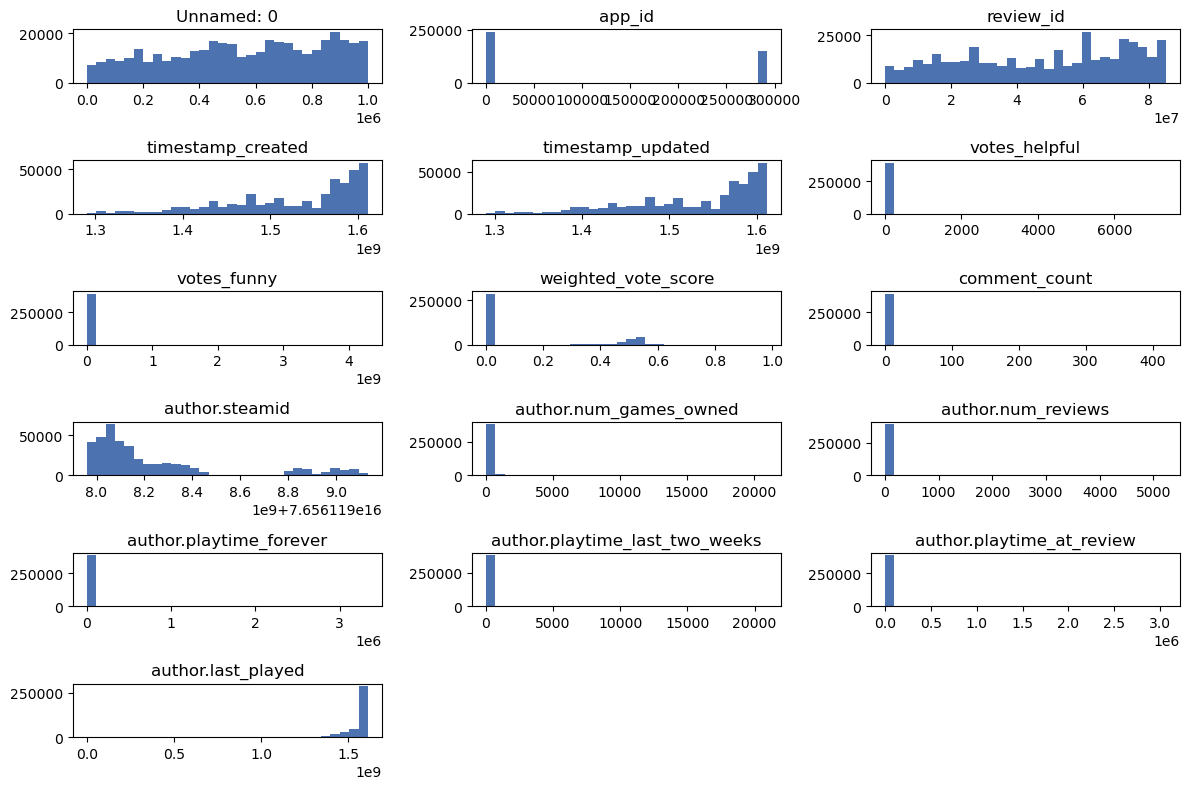

In [13]:
plot_distributions(df_eng)

In [14]:
cols_to_review = [
    'recommended', 'votes_helpful', 'votes_funny', 'weighted_vote_score',
    'comment_count', 'author.num_games_owned', 'author.num_reviews',
    ]
plot_pairplot_sample(df_eng, cols=cols_to_review, max_cols=len(cols_to_review))

In [15]:
cols_to_review = [
    'author.playtime_forever', 'author.playtime_last_two_weeks',
    'author.playtime_at_review', 'author.last_played'
    ]
plot_pairplot_sample(df_eng, cols=cols_to_review, max_cols=len(cols_to_review))

## 1. Class Balance

Class balance for 'recommended':
recommended
True     380303
False     12009
Name: count, dtype: int64

Class proportions for 'recommended':
recommended
True     0.969389
False    0.030611
Name: proportion, dtype: float64


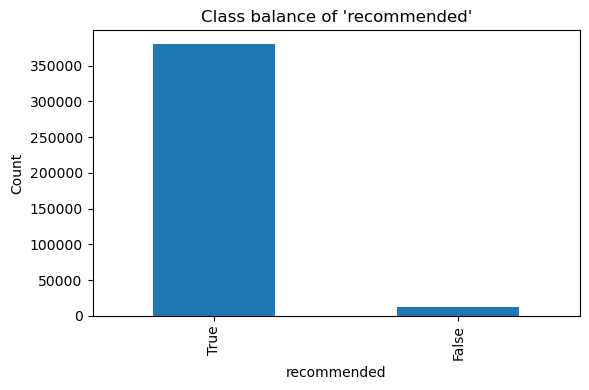

In [16]:
# To use the function:
show_class_balance(df_eng, col='recommended')

In [17]:
class_counts = df_eng['votes_helpful'].value_counts(dropna=False)
print(f"Class balance for '{'votes_helpful'}':")
print(class_counts)

Class balance for 'votes_helpful':
votes_helpful
0       293551
1        63462
2        16703
3         6074
4         2901
5         1674
6         1116
7          794
8          575
9          453
10         393
11         339
13         231
12         227
14         206
15         195
18         171
16         151
17         133
20         125
19         113
22          90
21          86
24          82
23          82
27          81
26          75
25          64
29          61
28          53
30          48
34          47
36          46
40          41
33          41
31          41
32          40
35          40
39          39
37          36
42          36
38          30
44          29
58          28
52          27
54          26
46          24
53          24
48          24
50          23
47          22
49          21
56          21
60          21
55          20
45          19
41          19
43          18
69          17
51          17
71          16
66          16
78          16
59    

In [18]:
print(f"\nClass proportions for 'votes_helpful':")
df_eng['votes_helpful'].value_counts(normalize=True, dropna=False)\
    .reindex(class_counts.index)\
    .fillna(0)



Class proportions for 'votes_helpful':


votes_helpful
0       0.748259
1       0.161764
2       0.042576
3       0.015483
4       0.007395
5       0.004267
6       0.002845
7       0.002024
8       0.001466
9       0.001155
10      0.001002
11      0.000864
13      0.000589
12      0.000579
14      0.000525
15      0.000497
18      0.000436
16      0.000385
17      0.000339
20      0.000319
19      0.000288
22      0.000229
21      0.000219
24      0.000209
23      0.000209
27      0.000206
26      0.000191
25      0.000163
29      0.000155
28      0.000135
30      0.000122
34      0.000120
36      0.000117
40      0.000105
33      0.000105
31      0.000105
32      0.000102
35      0.000102
39      0.000099
37      0.000092
42      0.000092
38      0.000076
44      0.000074
58      0.000071
52      0.000069
54      0.000066
46      0.000061
53      0.000061
48      0.000061
50      0.000059
47      0.000056
49      0.000054
56      0.000054
60      0.000054
55      0.000051
45      0.000048
41      0.000048
43      0.000046


<Axes: >

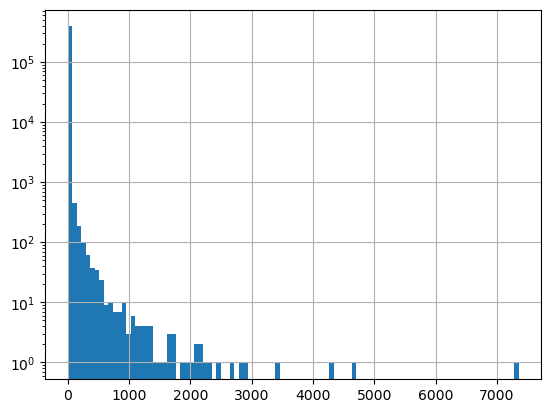

In [19]:
df_eng['votes_helpful'].hist(bins=100, log=True)

Summary for 'votes_helpful':
count    392312.000000
mean          1.404364
std          28.111198
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        7352.000000
Name: votes_helpful, dtype: float64

Top value counts:
votes_helpful
0    293551
1     63462
2     16703
3      6074
4      2901
5      1674
6      1116
7       794
8       575
9       453
Name: count, dtype: int64


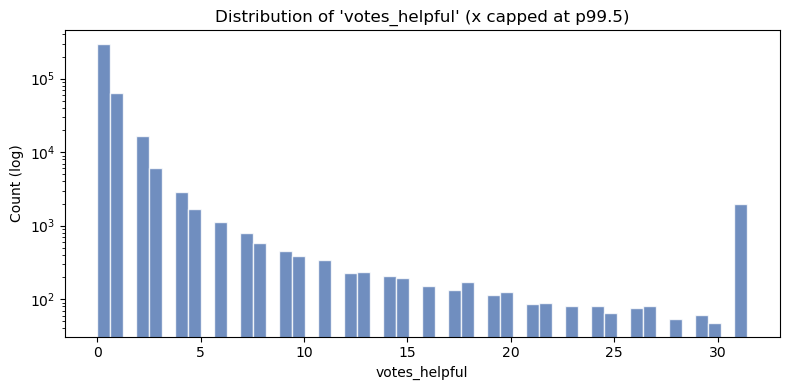

In [20]:
show_votes_helpful_distribution(df_eng)

### 2B - Data Distribution

In [21]:
from scipy import stats

def check_normality_and_skew(series, name=None, figsize=(12, 4), qq=True):
    """
    Plot histogram with normal overlay and optionally a Q-Q plot to assess normality and skew.
    Prints skewness (0 = symmetric, >0 = right skew, <0 = left skew).
    """
    s = series.dropna()
    name = name or getattr(series, "name", "value")
    
    fig, axes = plt.subplots(1, 2 if qq else 1, figsize=figsize)
    if qq:
        ax_hist, ax_qq = axes
    else:
        ax_hist = axes if isinstance(axes, plt.Axes) else axes[0]
    
    # Histogram + normal overlay
    n, bins, _ = ax_hist.hist(s, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="white", label="Data")
    mu, std = s.mean(), s.std()
    if std > 0:
        x = np.linspace(s.min(), s.max(), 200)
        ax_hist.plot(x, stats.norm.pdf(x, mu, std), "r-", lw=2, label="Normal (same μ, σ)")
    ax_hist.set_xlabel(name)
    ax_hist.set_ylabel("Density")
    ax_hist.set_title(f"Distribution of {name}")
    ax_hist.legend()
    
    # Q-Q plot: if points follow the red line, data is approximately normal; curve = skew
    if qq:
        stats.probplot(s, dist="norm", plot=ax_qq)
        ax_qq.set_title(f"Q-Q plot: {name}")
    
    skewness = s.skew()
    print(f"{name}: skewness = {skewness:.3f} (0=symmetric, >0=right skew, <0=left skew)")
    plt.tight_layout()
    plt.show()

In [22]:
def get_non_id_int_columns(df):
    """
    Returns columns in df that are integer-typed,
    excluding those related to 'Unnamed', IDs, or time/timestamp.
    """
    return [
        col for col in df.columns
        if (
            pd.api.types.is_integer_dtype(df[col])
            and not (
                col.startswith("Unnamed")
                or "id" in col
                or col.startswith("timestamp")
                or "time" in col
            )
        )
    ]


In [23]:
# Find number of records with votes_funny over 4e9

threshold = 4_000_000_000
count_high_votes_funny = (df_eng["votes_funny"] > threshold).sum()
print(f"Number of records with votes_funny over 4e9: {count_high_votes_funny}")
# Show ten records with votes_funny over 4e9 for inspection

high_votes_funny_records = df_eng[df_eng["votes_funny"] > threshold]
print(f"Displaying {min(5, len(high_votes_funny_records))} of {len(high_votes_funny_records)} records with votes_funny > 4e9:")
display(high_votes_funny_records.head(5))

# Explanation:
# This filters df_eng for records with votes_funny greater than 4 billion and displays up to ten of them
# so you can inspect the contents and perhaps spot if they are errors or outliers.

# Explanation:
# This counts and prints how many records in df_eng have votes_funny greater than 4,000,000,000.

Number of records with votes_funny over 4e9: 14
Displaying 5 of 14 records with votes_funny > 4e9:


,Unnamed: 0,app_id,app_name,review_id,language,review,timestamp_created,timestamp_updated,recommended,votes_helpful,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,author.steamid,author.num_games_owned,author.num_reviews,author.playtime_forever,author.playtime_last_two_weeks,author.playtime_at_review,author.last_played
376209,376209,292030,The Witcher 3: Wild Hunt,32891513,english,One of the best gaming experiences you will ev...,1498600047,1498600047,True,1,4294967295,0.502488,0,True,False,False,76561197980195272,280,10,14038.0,0.0,11867.0,1.567477e+09
377919,377919,292030,The Witcher 3: Wild Hunt,32552529,english,BBBBBBBBBBBBBBBBOOOOOOOOOOOOOOBBBBBBBBBBBBBBBB...,1497828421,1497828421,True,1,4294967295,0.502488,0,True,False,False,76561198240855902,63,9,38888.0,26.0,6211.0,1.611109e+09
380543,380543,292030,The Witcher 3: Wild Hunt,32091602,english,"to be honest, I was very sceptical when I star...",1496255452,1496255452,True,0,4294967295,0.000000,0,True,False,False,76561198023233186,965,40,1289.0,0.0,1145.0,1.522100e+09
387354,387354,292030,The Witcher 3: Wild Hunt,30562167,english,80 hours in and i got bored and can't play aga...,1489720950,1489720950,False,4,4294967295,0.223027,2,True,False,False,76561198129384137,132,19,4601.0,0.0,4542.0,1.598337e+09
390136,390136,292030,The Witcher 3: Wild Hunt,29869551,english,10/10\nOne of the best games ever made. It is ...,1486895796,1486895956,True,3,4294967295,0.545455,0,True,False,False,76561198240824978,54,6,8839.0,0.0,3550.0,1.602304e+09


In [24]:
# Get the record with the second highest votes_funny
second_max_votes_funny_idx = df_eng["votes_funny"].sort_values(ascending=False).index[1]
second_max_votes_funny_record = df_eng.loc[second_max_votes_funny_idx]
print("Record with second highest votes_funny:")
display(second_max_votes_funny_record)

Record with second highest votes_funny:


Unnamed: 0                                                                   396547
app_id                                                                       292030
app_name                                                   The Witcher 3: Wild Hunt
review_id                                                                  28578036
language                                                                    english
review                            Got this game out of curiosity and cos it was ...
timestamp_created                                                        1482546290
timestamp_updated                                                        1511407355
recommended                                                                    True
votes_helpful                                                                     1
votes_funny                                                              4294967295
weighted_vote_score                                                        0

In [25]:
# Basic stats on all numeric fields of df_eng
numeric_cols = get_non_id_int_columns(df_eng)
desc = df_eng[numeric_cols].describe().T

# Set float display precision and turn off scientific notation for this cell
with pd.option_context('display.float_format', '{:,.6f}'.format):
    desc["missing_pct"] = 1 - df_eng[numeric_cols].count() / len(df_eng)
    display(desc)

    print("\nColumn summaries:")
    for col in get_non_id_int_columns(df_eng):
        print(f"\n{col}:")
        print(f"  min      = {df_eng[col].min():,.6f}")
        print(f"  max      = {df_eng[col].max():,.6f}")
        print(f"  mean     = {df_eng[col].mean():,.6f}")
        print(f"  std      = {df_eng[col].std():,.6f}")
        print(f"  missing  = {df_eng[col].isna().sum()} ({df_eng[col].isna().mean():.2%})")

# Explanation:
# This gathers count, mean, std, min, 25/50/75%, max, and percent missing
# for each numeric column in df_eng, disables scientific notation for readability.

,count,mean,std,min,25%,50%,75%,max,missing_pct
votes_helpful,"392,312.000000",1.404364,28.111198,0.000000,0.000000,0.000000,1.000000,"7,352.000000",0.000000
votes_funny,"392,312.000000","153,270.422006","25,656,705.366489",0.000000,0.000000,0.000000,0.000000,"4,294,967,295.000000",0.000000
comment_count,"392,312.000000",0.122739,1.661280,0.000000,0.000000,0.000000,0.000000,420.000000,0.000000
author.num_games_owned,"392,312.000000",157.200889,305.055766,0.000000,32.000000,80.000000,176.000000,"20,969.000000",0.000000
author.num_reviews,"392,312.000000",13.546295,41.974909,1.000000,2.000000,5.000000,13.000000,"5,236.000000",0.000000



Column summaries:

votes_helpful:
  min      = 0.000000
  max      = 7,352.000000
  mean     = 1.404364
  std      = 28.111198
  missing  = 0 (0.00%)

votes_funny:
  min      = 0.000000
  max      = 4,294,967,295.000000
  mean     = 153,270.422006
  std      = 25,656,705.366489
  missing  = 0 (0.00%)

comment_count:
  min      = 0.000000
  max      = 420.000000
  mean     = 0.122739
  std      = 1.661280
  missing  = 0 (0.00%)

author.num_games_owned:
  min      = 0.000000
  max      = 20,969.000000
  mean     = 157.200889
  std      = 305.055766
  missing  = 0 (0.00%)

author.num_reviews:
  min      = 1.000000
  max      = 5,236.000000
  mean     = 13.546295
  std      = 41.974909
  missing  = 0 (0.00%)


votes_helpful: skewness = 103.702 (0=symmetric, >0=right skew, <0=left skew)


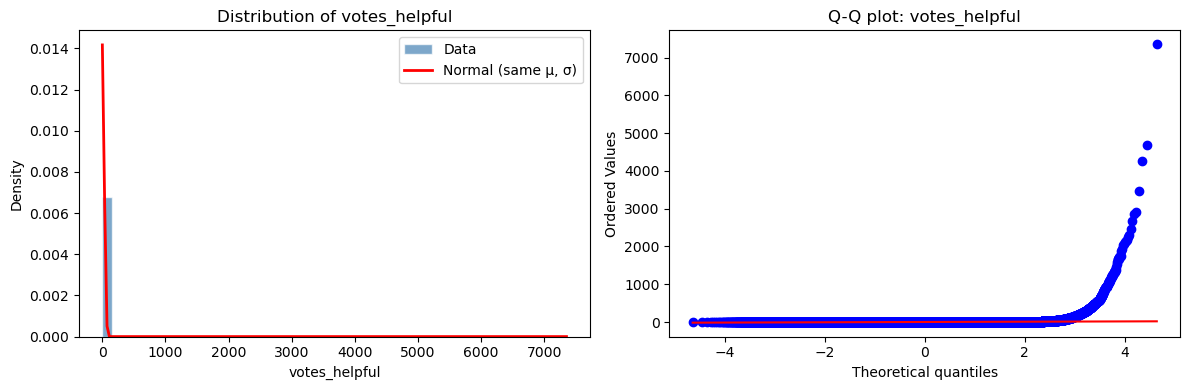

votes_funny: skewness = 167.390 (0=symmetric, >0=right skew, <0=left skew)


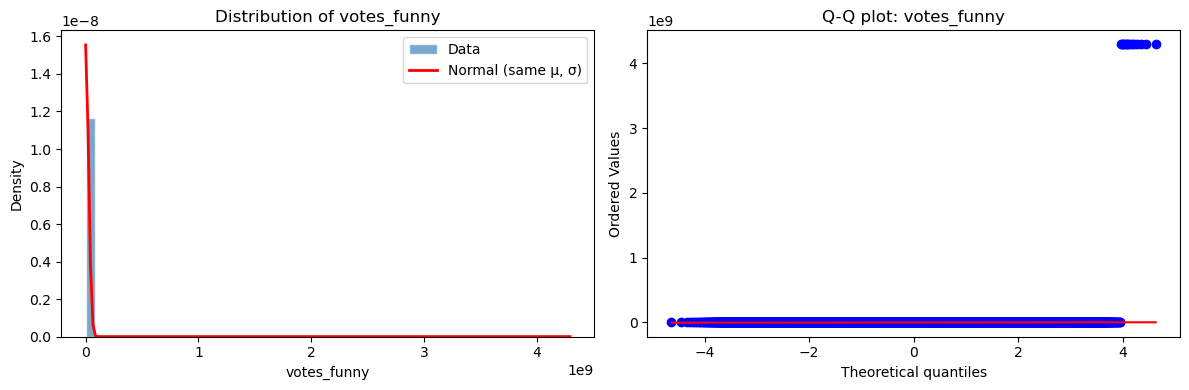

comment_count: skewness = 98.186 (0=symmetric, >0=right skew, <0=left skew)


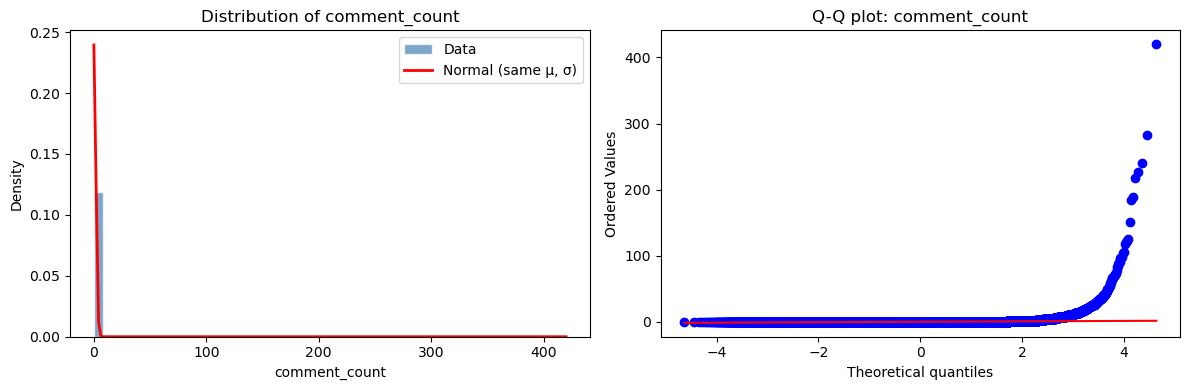

author.num_games_owned: skewness = 13.744 (0=symmetric, >0=right skew, <0=left skew)


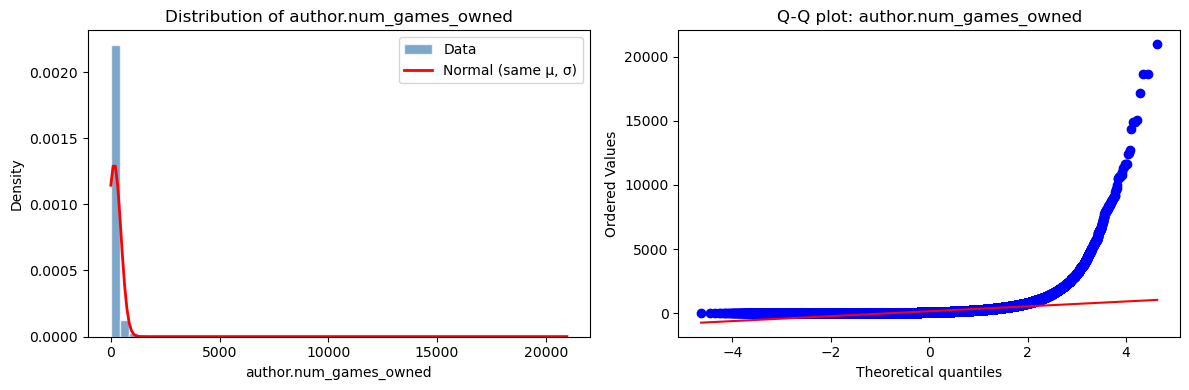

author.num_reviews: skewness = 43.056 (0=symmetric, >0=right skew, <0=left skew)


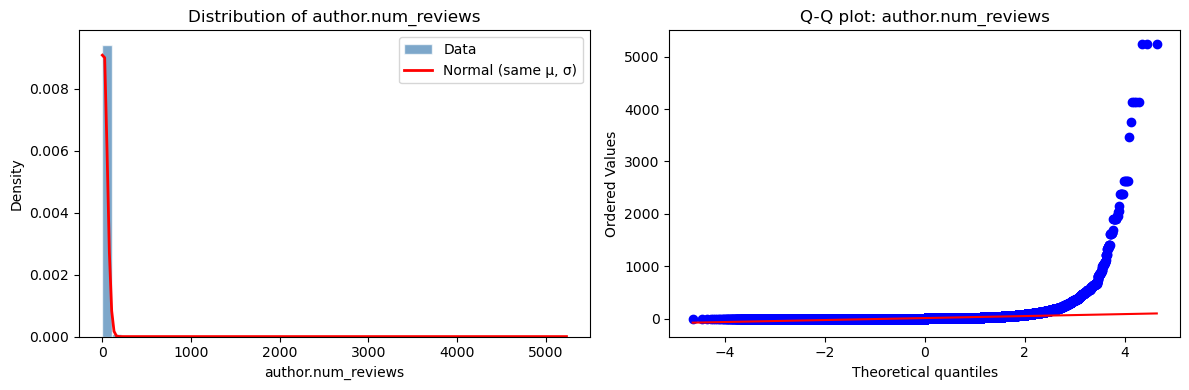

In [26]:
for col in get_non_id_int_columns(df_eng):
    check_normality_and_skew(df_eng[col].dropna(), name=col)

## 2. Crosstab or grouped bar of `recommended` vs binned `votes_helpful`

In [27]:
temp = df_eng.copy()

bins = [0, 1, 5, 10, 25, 50, 100, temp['votes_helpful'].max()]
labels = ['0','1-5','6-10','11-25','26-50','51-100','100+']

temp['helpful_bin'] = pd.cut(
    temp['votes_helpful'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
ct = pd.crosstab(temp['helpful_bin'], temp['recommended'])
print(ct)
ct_pct = pd.crosstab(
    temp['helpful_bin'],
    temp['recommended'],
    normalize='index'
)

recommended  False   True 
helpful_bin               
0             6141  350872
1-5           3599   23753
6-10          1195    2136
11-25          744    1551
26-50          190     764
51-100          71     531
100+            69     696


In [28]:

color_map = {
    True: "#2ca02c",
    False: "#d62728"
}

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{}, {}],
           [{"colspan": 2}, None]],
    subplot_titles=(
        "Recommended vs Helpful Votes (Count)",
        "Recommended vs Helpful Votes (Log Scale)",
        "Recommendation Rate by Helpful Votes"
    )
)

# ---- counts ----
for col in ct.columns:
    fig.add_trace(
        go.Bar(
            x=ct.index.astype(str),
            y=ct[col],
            name=str(col),
            marker_color=color_map[col],
            legendgroup=str(col)
        ),
        row=1, col=1
    )

# ---- log counts ----
for col in ct.columns:
    fig.add_trace(
        go.Bar(
            x=ct.index.astype(str),
            y=ct[col],
            name=str(col),
            marker_color=color_map[col],
            legendgroup=str(col),
            showlegend=False
        ),
        row=1, col=2
    )

fig.update_yaxes(type="log", row=1, col=2)

# ---- proportions ----
for col in ct_pct.columns:
    fig.add_trace(
        go.Bar(
            x=ct_pct.index.astype(str),
            y=ct_pct[col],
            name=str(col),
            marker_color=color_map[col],
            legendgroup=str(col),
            showlegend=False
        ),
        row=2, col=1
    )

fig.update_layout(
    barmode="group",
    height=700,
    xaxis_title="Helpful Vote Bin",
    yaxis_title="Count",
    yaxis2_title="Log Count",
    yaxis3_title="Proportion"
)

fig.show()


There are a lot more recommended games than not recommended games.
There are more game sthat have fewer helpful votes than more. this is expected.

Percentage graph is helpful. It shows there is definitely a difference in the proportions of Recommended and not Recommended depending on the helpfulneess.

When someone doesn't recommend a game, 

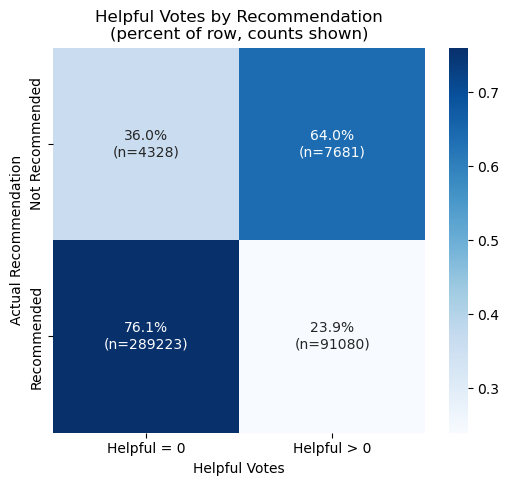

In [29]:
temp = df_eng.copy()

temp['helpful_gt_0'] = temp['votes_helpful'] > 0
cm = confusion_matrix(temp['recommended'], temp['helpful_gt_0'])

# row percentages
cm_percent = cm / cm.sum(axis=1, keepdims=True)

# build annotation: percent + count
annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    row_total = cm[i].sum()
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = cm_percent[i, j] * 100
        annot[i, j] = f"{pct:.1f}%\n(n={count})"

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_percent,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=["Helpful = 0", "Helpful > 0"],
    yticklabels=["Not Recommended", "Recommended"]
)

plt.xlabel("Helpful Votes")
plt.ylabel("Actual Recommendation")
plt.title("Helpful Votes by Recommendation\n(percent of row, counts shown)")
plt.show()
